In [5]:
# Price elasticity modeling notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [6]:
# Load cleaned daily dataset
daily = pd.read_csv("../data/processed/daily_aggregated.csv")

# Convert to datetime
daily["arrival_date"] = pd.to_datetime(daily["arrival_date"])

daily.head()

,arrival_date,daily_demand,avg_price,month,day_of_week,is_weekend
0,2015-07-01,100,95.368300,7,2,0
1,2015-07-02,36,99.188611,7,3,0
2,2015-07-03,37,99.524054,7,4,0
3,2015-07-04,44,90.669091,7,5,1
4,2015-07-05,37,107.966486,7,6,1


In [7]:
print("Dataset shape:", daily.shape)

# Remove zero values (log undefined)
daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

print("After removing zero values:", daily.shape)

Dataset shape: (793, 6)
After removing zero values: (793, 6)


In [8]:
daily["log_demand"] = np.log(daily["daily_demand"])
daily["log_price"] = np.log(daily["avg_price"])

daily[["log_demand", "log_price"]].head()

,log_demand,log_price
0,4.605170,4.557746
1,3.583519,4.597023
2,3.610918,4.600399
3,3.784190,4.507217
4,3.610918,4.681821


In [9]:
# Prepare model inputs
X = daily[["log_price"]]
y = daily["log_demand"]

# Train regression model
model = LinearRegression()
model.fit(X, y)

# Extract elasticity
elasticity = model.coef_[0]

print("Estimated Price Elasticity:", round(elasticity, 3))

Estimated Price Elasticity: 0.408


In [10]:
if elasticity < -1:
    print("Demand is elastic (customers are price sensitive).")
elif -1 < elasticity < 0:
    print("Demand is inelastic (customers are less sensitive to price).")
else:
    print("Unexpected elasticity value — check data quality.")

Unexpected elasticity value — check data quality.


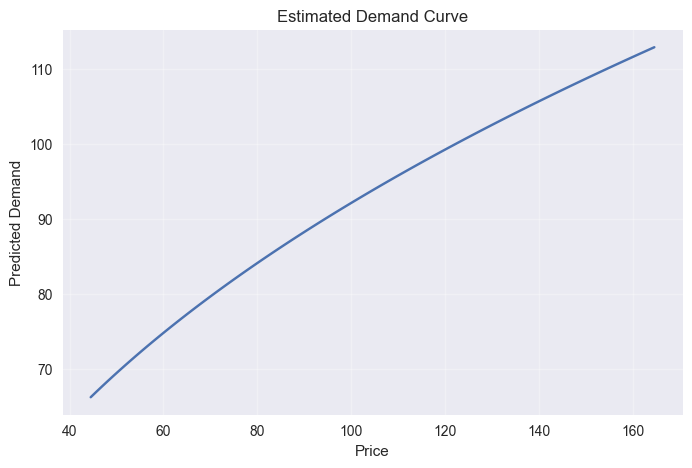

In [11]:
# Create smooth price range
price_range = np.linspace(
    daily["avg_price"].min(),
    daily["avg_price"].max(),
    100
)

# Base demand level
base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

# Constant elasticity demand function
predicted_demand = base_demand * (price_range / reference_price) ** elasticity

plt.figure(figsize=(8,5))
plt.plot(price_range, predicted_demand)
plt.title("Estimated Demand Curve")
plt.xlabel("Price")
plt.ylabel("Predicted Demand")
plt.grid(alpha=0.3)
plt.show()

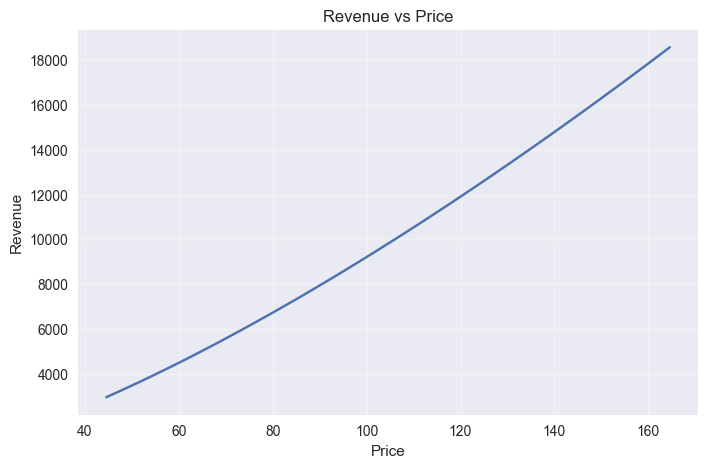

In [12]:
revenue = price_range * predicted_demand

plt.figure(figsize=(8,5))
plt.plot(price_range, revenue)
plt.title("Revenue vs Price")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

In [13]:
optimal_index = np.argmax(revenue)

optimal_price = price_range[optimal_index]
optimal_revenue = revenue[optimal_index]

print("Unconstrained Optimal Price:", round(optimal_price, 2))
print("Maximum Revenue:", round(optimal_revenue, 2))

Unconstrained Optimal Price: 164.59
Maximum Revenue: 18588.05
